# Análisis de las clases minoritarias RRe y aRRd

## Objetivo

Este análisis estudia cómo se representan las curvas de luz RRe y aRRd en el espacio definido por los cinco arquetipos seleccionados previamente. Estas observaciones se mantuvieron fuera del entrenamiento, la selección de parámetros y la evaluación principal debido a su baja frecuencia en el conjunto de datos.

Las curvas minoritarias se proyectarán sobre los arquetipos ya entrenados, sin modificar el modelo AA. Se analizarán sus coeficientes \(\alpha\), la dominancia del arquetipo principal, el margen entre los dos coeficientes mayores, la entropía y el error de reconstrucción. También se estudiará su relación con las regiones densas identificadas para RRab, RRc y RRd.

La unidad de análisis continúa siendo cada curva de luz. Por lo tanto, las observaciones procedentes de OGLE-III y OGLE-IV se mantienen como instancias separadas cuando ambas están disponibles para una misma estrella física.

In [1]:
from pathlib import Path
import sys
import inspect
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from scipy.optimize import nnls
from itertools import combinations
from scipy.stats import mannwhitneyu

from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors


def encontrar_raiz_proyecto():
    """Busca la raíz del proyecto desde el directorio actual."""

    ruta_actual = Path.cwd().resolve()

    for ruta_candidata in (
        ruta_actual,
        *ruta_actual.parents,
    ):
        tiene_src = (
            ruta_candidata
            / "src"
        ).is_dir()

        tiene_notebooks = (
            ruta_candidata
            / "notebooks"
        ).is_dir()

        if tiene_src and tiene_notebooks:
            return ruta_candidata

    raise FileNotFoundError(
        "No se encontró la raíz del proyecto."
    )


RUTA_PROYECTO = encontrar_raiz_proyecto()

print(
    "Raíz del proyecto:",
    RUTA_PROYECTO,
)


# Permitir que Python encuentre los módulos de src
if str(RUTA_PROYECTO) not in sys.path:
    sys.path.insert(
        0,
        str(RUTA_PROYECTO),
    )


from src.loaders import cargar_dataset
from src.normalizacion import aplicar_normalizacion


sns.set_theme(
    style="whitegrid",
    context="notebook",
)

Raíz del proyecto: C:\Users\adanm\Code\tesis


In [2]:
datos_mediana_50 = cargar_dataset(
    "medianas_fase_50"
)


resumen_particiones = []


for nombre, contenido in datos_mediana_50.items():

    if not isinstance(contenido, dict):
        continue

    if "X" not in contenido:
        continue

    X = contenido["X"]
    metadata = contenido.get("metadata")

    subtipos = None

    if (
        metadata is not None
        and "subtipo_rrlyrae" in metadata.columns
    ):
        subtipos = (
            metadata["subtipo_rrlyrae"]
            .value_counts()
            .to_dict()
        )

    resumen_particiones.append(
        {
            "particion": nombre,
            "forma_X": X.shape,
            "filas_metadata": (
                len(metadata)
                if metadata is not None
                else None
            ),
            "subtipos": subtipos,
        }
    )


print(
    "Claves disponibles:",
    list(datos_mediana_50.keys()),
)

display(
    pd.DataFrame(resumen_particiones)
)

Claves disponibles: ['train', 'val', 'test']


,particion,forma_X,filas_metadata,subtipos
0,train,"(61466, 50)",61466,"{'RRab': 44087, 'RRc': 15281, 'RRd': 2098}"
1,val,"(20576, 50)",20576,"{'RRab': 14895, 'RRc': 5073, 'RRd': 608}"
2,test,"(20537, 50)",20537,"{'RRab': 14618, 'RRc': 5272, 'RRd': 647}"


In [3]:
terminos_busqueda = [
    "minorit",
    "rre",
    "arrd",
    "medianas_fase_50",
    "curvas_plegadas",
    "catalogo_maestro",
]


archivos_candidatos = []


for ruta in (
    RUTA_PROYECTO / "data"
).rglob("*"):

    if not ruta.is_file():
        continue

    nombre_minuscula = ruta.name.lower()

    if not any(
        termino in nombre_minuscula
        for termino in terminos_busqueda
    ):
        continue

    archivos_candidatos.append(
        {
            "archivo": str(
                ruta.relative_to(
                    RUTA_PROYECTO
                )
            ),
            "extension": ruta.suffix.lower(),
            "tamano_mb": (
                ruta.stat().st_size
                / 1024**2
            ),
        }
    )


df_archivos_candidatos = (
    pd.DataFrame(archivos_candidatos)
    .sort_values("archivo")
    .reset_index(drop=True)
)


display(
    df_archivos_candidatos.round(
        {"tamano_mb": 2}
    )
)

,archivo,extension,tamano_mb
0,data\interim\catalogo_maestro.csv,.csv,41.53
1,data\interim\catalogo_maestro_corregido.csv,.csv,47.00
2,data\interim\catalogo_maestro_final.csv,.csv,44.93
3,data\interim\curvas_aRRd_modo_fundamental.parquet,.parquet,0.14
4,data\interim\curvas_plegadas.parquet,.parquet,1184.92
5,data\interim\curvas_plegadas_corregidas.parquet,.parquet,1184.92
6,data\interim\curvas_plegadas_final.parquet,.parquet,1178.72
7,data\processed\discretizaciones\medianas_fase_...,.parquet,10.42
8,data\raw\periods\OGLE-III-LMC-RRe.dat,.dat,0.12
9,data\raw\periods\OGLE-III-SMC-RRe.dat,.dat,0.01


In [4]:
rutas_mediana_50 = sorted(
    (
        RUTA_PROYECTO
        / "data"
        / "processed"
        / "discretizaciones"
    ).glob("medianas_fase_50*.parquet")
)


print("Archivos encontrados:")

for ruta in rutas_mediana_50:
    print("-", ruta)


if len(rutas_mediana_50) != 1:
    raise ValueError(
        "Se esperaba encontrar exactamente un "
        "archivo de medianas_fase_50."
    )


RUTA_MEDIANAS_50_COMPLETA = (
    rutas_mediana_50[0]
)


df_medianas_50_completa = pd.read_parquet(
    RUTA_MEDIANAS_50_COMPLETA
)


print(
    "\nDimensiones:",
    df_medianas_50_completa.shape,
)

print(
    "\nPrimeras columnas:",
    df_medianas_50_completa.columns[
        :10
    ].tolist(),
)

print(
    "\nÚltimas columnas:",
    df_medianas_50_completa.columns[
        -10:
    ].tolist(),
)


columnas_interes = [
    columna
    for columna in [
        "observacion_id",
        "star_id_base",
        "subtipo_rrlyrae",
        "survey",
        "campo",
    ]
    if columna
    in df_medianas_50_completa.columns
]


if columnas_interes:
    display(
        df_medianas_50_completa[
            columnas_interes
        ].head()
    )


if (
    "subtipo_rrlyrae"
    in df_medianas_50_completa.columns
):
    display(
        df_medianas_50_completa[
            "subtipo_rrlyrae"
        ].value_counts(
            dropna=False
        )
    )

Archivos encontrados:
- C:\Users\adanm\Code\tesis\data\processed\discretizaciones\medianas_fase_50.parquet

Dimensiones: (102778, 51)

Primeras columnas: ['observacion_id', 'magnitud_000', 'magnitud_001', 'magnitud_002', 'magnitud_003', 'magnitud_004', 'magnitud_005', 'magnitud_006', 'magnitud_007', 'magnitud_008']

Últimas columnas: ['magnitud_040', 'magnitud_041', 'magnitud_042', 'magnitud_043', 'magnitud_044', 'magnitud_045', 'magnitud_046', 'magnitud_047', 'magnitud_048', 'magnitud_049']


,observacion_id
0,OGLEIII_OGLE-LMC-RRLYR-00001
1,OGLEIII_OGLE-LMC-RRLYR-00002
2,OGLEIII_OGLE-LMC-RRLYR-00003
3,OGLEIII_OGLE-LMC-RRLYR-00004
4,OGLEIII_OGLE-LMC-RRLYR-00005


In [5]:
RUTA_CATALOGO = (
    RUTA_PROYECTO
    / "data"
    / "interim"
    / "catalogo_maestro_final.csv"
)


catalogo_maestro = pd.read_csv(
    RUTA_CATALOGO
)


print(
    "Dimensiones del catálogo:",
    catalogo_maestro.shape,
)

print(
    "Observaciones únicas:",
    catalogo_maestro[
        "observacion_id"
    ].nunique(),
)


# Columnas que representan la curva discretizada
columnas_magnitud = [
    columna
    for columna
    in df_medianas_50_completa.columns
    if columna.startswith("magnitud_")
]


# Unir representación y metadatos
df_medianas_catalogo = (
    df_medianas_50_completa
    .merge(
        catalogo_maestro,
        on="observacion_id",
        how="inner",
        validate="one_to_one",
    )
)


# Extraer solamente RRe y aRRd
df_minoritarias = (
    df_medianas_catalogo.loc[
        df_medianas_catalogo[
            "subtipo_rrlyrae"
        ].isin(["RRe", "aRRd"])
    ]
    .copy()
    .reset_index(drop=True)
)


X_minoritarias_original = (
    df_minoritarias[
        columnas_magnitud
    ]
    .to_numpy(dtype=float)
)


metadata_minoritarias = (
    df_minoritarias.drop(
        columns=columnas_magnitud
    )
    .copy()
)


resumen_minoritarias = pd.Series(
    {
        "filas_totales": len(
            df_minoritarias
        ),
        "numero_variables": (
            X_minoritarias_original.shape[1]
        ),
        "observaciones_unicas": (
            metadata_minoritarias[
                "observacion_id"
            ].nunique()
        ),
        "estrellas_fisicas": (
            metadata_minoritarias[
                "star_id_base"
            ].nunique()
            if "star_id_base"
            in metadata_minoritarias.columns
            else np.nan
        ),
        "valores_faltantes_X": int(
            np.isnan(
                X_minoritarias_original
            ).sum()
        ),
    },
    name="resultado",
)


display(resumen_minoritarias)

display(
    metadata_minoritarias[
        "subtipo_rrlyrae"
    ].value_counts()
)

Dimensiones del catálogo: (102778, 37)
Observaciones únicas: 102778


filas_totales           199
numero_variables         50
observaciones_unicas    199
estrellas_fisicas       199
valores_faltantes_X       0
Name: resultado, dtype: int64

subtipo_rrlyrae
RRe     177
aRRd     22
Name: count, dtype: int64

In [7]:
# Revisar la implementación exacta de la normalización
print("FUNCIÓN DE NORMALIZACIÓN\n")

print(
    inspect.getsource(
        aplicar_normalizacion
    )
)


# Inspeccionar los artefactos del AA representativo
ID_AA_REFERENCIA = "976409505a67e4f6"

RUTA_AA_REFERENCIA = (
    RUTA_PROYECTO
    / "resultados"
    / "experimentos"
    / ID_AA_REFERENCIA
)


archivos_aa_referencia = []


for ruta in sorted(
    RUTA_AA_REFERENCIA.rglob("*")
):
    if not ruta.is_file():
        continue

    archivos_aa_referencia.append(
        {
            "archivo": str(
                ruta.relative_to(
                    RUTA_AA_REFERENCIA
                )
            ),
            "extension": ruta.suffix,
            "tamano_kb": (
                ruta.stat().st_size
                / 1024
            ),
        }
    )


print(
    "\nARTEFACTOS DEL AA REPRESENTATIVO\n"
)

display(
    pd.DataFrame(
        archivos_aa_referencia
    ).round(
        {"tamano_kb": 2}
    )
)

FUNCIÓN DE NORMALIZACIÓN

def aplicar_normalizacion(X, metodo):
    """APlicar la normalización indicada."""
    metodos = {
        "minmax": minmax_normalization,
        "centered": centered_normalization,
        "zscore": zscore_normalization,
    }
    if metodo not in metodos:
        raise ValueError(f"Metodo de normalización no reconocido: {metodo}")

    return metodos[metodo](X)


ARTEFACTOS DEL AA REPRESENTATIVO



,archivo,extension,tamano_kb
0,alphas_train.npy,.npy,2401.14
1,alphas_val.npy,.npy,803.88
2,betas.npy,.npy,2401.14
3,config.json,.json,0.57
4,grupos_train.npy,.npy,480.33
5,grupos_val.npy,.npy,160.88
6,ids_train.npy,.npy,6722.97
7,ids_val.npy,.npy,2250.62
8,patrones.npy,.npy,2.08


In [9]:
arquetipos_aa = np.load(
    RUTA_AA_REFERENCIA
    / "patrones.npy"
)


print(
    "Forma de los arquetipos:",
    arquetipos_aa.shape,
)

print(
    "Valores mínimo y máximo:",
    arquetipos_aa.min(),
    arquetipos_aa.max(),
)

Forma de los arquetipos: (5, 50)
Valores mínimo y máximo: 0.006630599870043591 0.9950205103928276


In [10]:
def proyectar_aa_nnls(
    X,
    arquetipos,
    constante=100.0,
    max_iter=100,
):
    """
    Proyectar curvas sobre arquetipos fijos mediante NNLS.

    La fila adicional impone aproximadamente que los
    coeficientes sumen uno. Después se normalizan para
    asegurar la pertenencia al simplex.
    """

    X = np.asarray(
        X,
        dtype=np.float64,
    )

    arquetipos = np.asarray(
        arquetipos,
        dtype=np.float64,
    )

    n_curvas = X.shape[0]
    n_arquetipos = arquetipos.shape[0]

    matriz_nnls = np.vstack(
        [
            arquetipos.T,
            constante * np.ones(
                (1, n_arquetipos)
            ),
        ]
    )

    coeficientes = np.empty(
        (n_curvas, n_arquetipos),
        dtype=np.float64,
    )

    for indice, curva in enumerate(X):

        vector_nnls = np.concatenate(
            [
                curva,
                np.array([constante]),
            ]
        )

        coeficientes_curva, _ = nnls(
            matriz_nnls,
            vector_nnls,
            maxiter=max_iter,
        )

        suma = coeficientes_curva.sum()

        if suma <= 0:
            raise ValueError(
                f"Los coeficientes de la curva "
                f"{indice} no tienen una suma "
                "positiva."
            )

        coeficientes[indice] = (
            coeficientes_curva / suma
        )

    grupos = np.argmax(
        coeficientes,
        axis=1,
    )

    X_reconstruida = (
        coeficientes @ arquetipos
    )

    return (
        coeficientes,
        grupos,
        X_reconstruida,
    )


# Normalizar cada curva minoritaria
X_minoritarias_aa = aplicar_normalizacion(
    X_minoritarias_original,
    "minmax",
)


# Proyectar sobre los cinco arquetipos fijos
(
    alphas_minoritarias,
    grupos_minoritarias,
    X_reconstruida_minoritarias,
) = proyectar_aa_nnls(
    X_minoritarias_aa,
    arquetipos_aa,
)


# Error de reconstrucción por curva
mse_minoritarias = np.mean(
    (
        X_minoritarias_aa
        - X_reconstruida_minoritarias
    ) ** 2,
    axis=1,
)


# Comprobaciones
resumen_proyeccion = pd.Series(
    {
        "forma_X_normalizada": (
            X_minoritarias_aa.shape
        ),
        "forma_alphas": (
            alphas_minoritarias.shape
        ),
        "forma_reconstruccion": (
            X_reconstruida_minoritarias.shape
        ),
        "suma_alpha_minima": (
            alphas_minoritarias
            .sum(axis=1)
            .min()
        ),
        "suma_alpha_maxima": (
            alphas_minoritarias
            .sum(axis=1)
            .max()
        ),
        "alpha_minimo": (
            alphas_minoritarias.min()
        ),
        "alpha_maximo": (
            alphas_minoritarias.max()
        ),
        "mse_medio": (
            mse_minoritarias.mean()
        ),
        "mse_maximo": (
            mse_minoritarias.max()
        ),
    },
    name="resultado",
)


display(resumen_proyeccion)

forma_X_normalizada     (199, 50)
forma_alphas             (199, 5)
forma_reconstruccion    (199, 50)
suma_alpha_minima             1.0
suma_alpha_maxima             1.0
alpha_minimo                  0.0
alpha_maximo             0.871988
mse_medio                0.016315
mse_maximo               0.045161
Name: resultado, dtype: object

In [11]:
# Coeficiente dominante y segundo coeficiente mayor
alphas_ordenados = np.sort(
    alphas_minoritarias,
    axis=1,
)

alpha_maximo_minoritarias = (
    alphas_ordenados[:, -1]
)

segundo_alpha_minoritarias = (
    alphas_ordenados[:, -2]
)

margen_minoritarias = (
    alpha_maximo_minoritarias
    - segundo_alpha_minoritarias
)


# Entropía normalizada en el intervalo [0, 1]
entropia_minoritarias = -np.sum(
    np.where(
        alphas_minoritarias > 0,
        alphas_minoritarias
        * np.log(alphas_minoritarias),
        0.0,
    ),
    axis=1,
) / np.log(
    alphas_minoritarias.shape[1]
)


# Construir tabla por observación
columnas_metadata_resultado = [
    columna
    for columna in [
        "observacion_id",
        "star_id_base",
        "subtipo_rrlyrae",
        "survey",
        "region",
    ]
    if columna
    in metadata_minoritarias.columns
]


df_resultados_minoritarias = (
    metadata_minoritarias[
        columnas_metadata_resultado
    ]
    .copy()
)


for indice in range(
    alphas_minoritarias.shape[1]
):
    df_resultados_minoritarias[
        f"alpha_{indice + 1}"
    ] = alphas_minoritarias[:, indice]


df_resultados_minoritarias[
    "arquetipo_dominante"
] = grupos_minoritarias + 1

df_resultados_minoritarias[
    "alpha_maximo"
] = alpha_maximo_minoritarias

df_resultados_minoritarias[
    "segundo_alpha"
] = segundo_alpha_minoritarias

df_resultados_minoritarias[
    "margen"
] = margen_minoritarias

df_resultados_minoritarias[
    "entropia"
] = entropia_minoritarias

df_resultados_minoritarias[
    "mse_reconstruccion"
] = mse_minoritarias


# Resumen de mezcla y reconstrucción
resumen_mezcla_minoritarias = (
    df_resultados_minoritarias
    .groupby("subtipo_rrlyrae")
    .agg(
        n=(
            "observacion_id",
            "size",
        ),
        alpha_maximo_media=(
            "alpha_maximo",
            "mean",
        ),
        alpha_maximo_mediana=(
            "alpha_maximo",
            "median",
        ),
        margen_medio=(
            "margen",
            "mean",
        ),
        margen_mediano=(
            "margen",
            "median",
        ),
        entropia_media=(
            "entropia",
            "mean",
        ),
        entropia_mediana=(
            "entropia",
            "median",
        ),
        mse_medio=(
            "mse_reconstruccion",
            "mean",
        ),
        mse_mediano=(
            "mse_reconstruccion",
            "median",
        ),
    )
    .reset_index()
)


# Distribución del arquetipo dominante
tabla_arquetipo_conteo = pd.crosstab(
    df_resultados_minoritarias[
        "subtipo_rrlyrae"
    ],
    df_resultados_minoritarias[
        "arquetipo_dominante"
    ],
)


tabla_arquetipo_porcentaje = (
    pd.crosstab(
        df_resultados_minoritarias[
            "subtipo_rrlyrae"
        ],
        df_resultados_minoritarias[
            "arquetipo_dominante"
        ],
        normalize="index",
    )
    * 100
)


display(
    resumen_mezcla_minoritarias.round(4)
)

print(
    "\nNúmero de curvas por arquetipo dominante:"
)

display(tabla_arquetipo_conteo)

print(
    "\nPorcentaje dentro de cada subtipo:"
)

display(
    tabla_arquetipo_porcentaje.round(2)
)

C:\Users\adanm\AppData\Local\Temp\ipykernel_2856\860108774.py:26: RuntimeWarning: divide by zero encountered in log
  * np.log(alphas_minoritarias),
C:\Users\adanm\AppData\Local\Temp\ipykernel_2856\860108774.py:25: RuntimeWarning: invalid value encountered in multiply
  alphas_minoritarias


,subtipo_rrlyrae,n,alpha_maximo_media,alpha_maximo_mediana,margen_medio,margen_mediano,entropia_media,entropia_mediana,mse_medio,mse_mediano
0,RRe,177,0.4800,0.4704,0.1842,0.1601,0.7031,0.7272,0.0162,0.0147
1,aRRd,22,0.4829,0.4509,0.1872,0.1158,0.6812,0.6899,0.0170,0.0147



Número de curvas por arquetipo dominante:


arquetipo_dominante,1,2,3,4,5
subtipo_rrlyrae,,,,,
RRe,19,92,4,7,55
aRRd,0,7,12,0,3



Porcentaje dentro de cada subtipo:


arquetipo_dominante,1,2,3,4,5
subtipo_rrlyrae,,,,,
RRe,10.73,51.98,2.26,3.95,31.07
aRRd,0.00,31.82,54.55,0.00,13.64


In [13]:
# ---------------------------------------------------------
# Cargar los coeficientes del test principal
# ---------------------------------------------------------

RUTA_EVALUACION_TEST = (
    RUTA_PROYECTO
    / "resultados"
    / "evaluacion_test_corregida"
)

RUTA_ARTEFACTOS_AA_TEST = (
    RUTA_EVALUACION_TEST
    / "artefactos"
    / ID_AA_REFERENCIA
)


alphas_test_principal = np.load(
    RUTA_ARTEFACTOS_AA_TEST
    / "alphas_test.npy"
)

ids_test_guardados = np.load(
    RUTA_EVALUACION_TEST
    / "ids_test.npy",
    allow_pickle=True,
)


X_test_original = (
    datos_mediana_50["test"]["X"]
)

metadata_test_principal = (
    datos_mediana_50["test"]["metadata"]
    .copy()
    .reset_index(drop=True)
)


ids_test_actuales = (
    metadata_test_principal[
        "observacion_id"
    ]
    .to_numpy()
)


if not np.array_equal(
    ids_test_guardados,
    ids_test_actuales,
):
    raise ValueError(
        "El orden del test principal no coincide "
        "con los coeficientes guardados."
    )


# ---------------------------------------------------------
# Reconstrucción e indicadores del conjunto principal
# ---------------------------------------------------------

X_test_principal_aa = aplicar_normalizacion(
    X_test_original,
    "minmax",
)

X_reconstruida_principal = (
    alphas_test_principal
    @ arquetipos_aa
)

mse_test_principal = np.mean(
    (
        X_test_principal_aa
        - X_reconstruida_principal
    ) ** 2,
    axis=1,
)


def calcular_indicadores_mezcla(alphas):

    alphas_ordenados = np.sort(
        alphas,
        axis=1,
    )

    alpha_maximo = (
        alphas_ordenados[:, -1]
    )

    segundo_alpha = (
        alphas_ordenados[:, -2]
    )

    margen = (
        alpha_maximo
        - segundo_alpha
    )

    alphas_seguros = np.clip(
        alphas,
        1e-15,
        1.0,
    )

    entropia = -np.sum(
        alphas
        * np.log(alphas_seguros),
        axis=1,
    ) / np.log(
        alphas.shape[1]
    )

    return (
        alpha_maximo,
        segundo_alpha,
        margen,
        entropia,
    )


(
    alpha_maximo_principal,
    segundo_alpha_principal,
    margen_principal,
    entropia_principal,
) = calcular_indicadores_mezcla(
    alphas_test_principal
)


# ---------------------------------------------------------
# Construir tabla comparable
# ---------------------------------------------------------

columnas_metadata_principal = [
    columna
    for columna in [
        "observacion_id",
        "star_id_base",
        "subtipo_rrlyrae",
        "survey",
        "region",
    ]
    if columna
    in metadata_test_principal.columns
]


df_resultados_principal = (
    metadata_test_principal[
        columnas_metadata_principal
    ]
    .copy()
)


for indice in range(
    alphas_test_principal.shape[1]
):
    df_resultados_principal[
        f"alpha_{indice + 1}"
    ] = alphas_test_principal[:, indice]


df_resultados_principal[
    "arquetipo_dominante"
] = (
    np.argmax(
        alphas_test_principal,
        axis=1,
    )
    + 1
)

df_resultados_principal[
    "alpha_maximo"
] = alpha_maximo_principal

df_resultados_principal[
    "segundo_alpha"
] = segundo_alpha_principal

df_resultados_principal[
    "margen"
] = margen_principal

df_resultados_principal[
    "entropia"
] = entropia_principal

df_resultados_principal[
    "mse_reconstruccion"
] = mse_test_principal


df_comparacion_subtipos = pd.concat(
    [
        df_resultados_principal,
        df_resultados_minoritarias,
    ],
    ignore_index=True,
)


orden_subtipos = [
    "RRab",
    "RRc",
    "RRd",
    "RRe",
    "aRRd",
]


resumen_comparacion_subtipos = (
    df_comparacion_subtipos
    .groupby("subtipo_rrlyrae")
    .agg(
        n=(
            "observacion_id",
            "size",
        ),
        alpha_maximo_media=(
            "alpha_maximo",
            "mean",
        ),
        alpha_maximo_mediana=(
            "alpha_maximo",
            "median",
        ),
        margen_medio=(
            "margen",
            "mean",
        ),
        margen_mediano=(
            "margen",
            "median",
        ),
        entropia_media=(
            "entropia",
            "mean",
        ),
        entropia_mediana=(
            "entropia",
            "median",
        ),
        mse_medio=(
            "mse_reconstruccion",
            "mean",
        ),
        mse_mediano=(
            "mse_reconstruccion",
            "median",
        ),
    )
    .reindex(orden_subtipos)
    .reset_index()
)


tabla_alphas_promedio = (
    df_comparacion_subtipos
    .groupby("subtipo_rrlyrae")[
        [
            "alpha_1",
            "alpha_2",
            "alpha_3",
            "alpha_4",
            "alpha_5",
        ]
    ]
    .mean()
    .reindex(orden_subtipos)
)


display(
    resumen_comparacion_subtipos.round(4)
)

print(
    "\nCoeficientes alfa medios:"
)

display(
    tabla_alphas_promedio.round(4)
)

,subtipo_rrlyrae,n,alpha_maximo_media,alpha_maximo_mediana,margen_medio,margen_mediano,entropia_media,entropia_mediana,mse_medio,mse_mediano
0,RRab,14618,0.6068,0.5977,0.2958,0.2708,0.5093,0.4925,0.0031,0.0022
1,RRc,5272,0.6432,0.6373,0.3978,0.3854,0.5202,0.5238,0.0052,0.0039
2,RRd,647,0.4719,0.4549,0.1956,0.1483,0.7266,0.7493,0.0139,0.0129
3,RRe,177,0.4800,0.4704,0.1842,0.1601,0.7031,0.7272,0.0162,0.0147
4,aRRd,22,0.4829,0.4509,0.1872,0.1158,0.6812,0.6899,0.0170,0.0147



Coeficientes alfa medios:


,alpha_1,alpha_2,alpha_3,alpha_4,alpha_5
subtipo_rrlyrae,,,,,
RRab,0.2105,0.0186,0.3818,0.3576,0.0315
RRc,0.1384,0.1670,0.0537,0.0389,0.6020
RRd,0.3008,0.1381,0.1977,0.0590,0.3044
RRe,0.1569,0.3778,0.0895,0.1145,0.2613
aRRd,0.1093,0.2846,0.4064,0.0448,0.1549


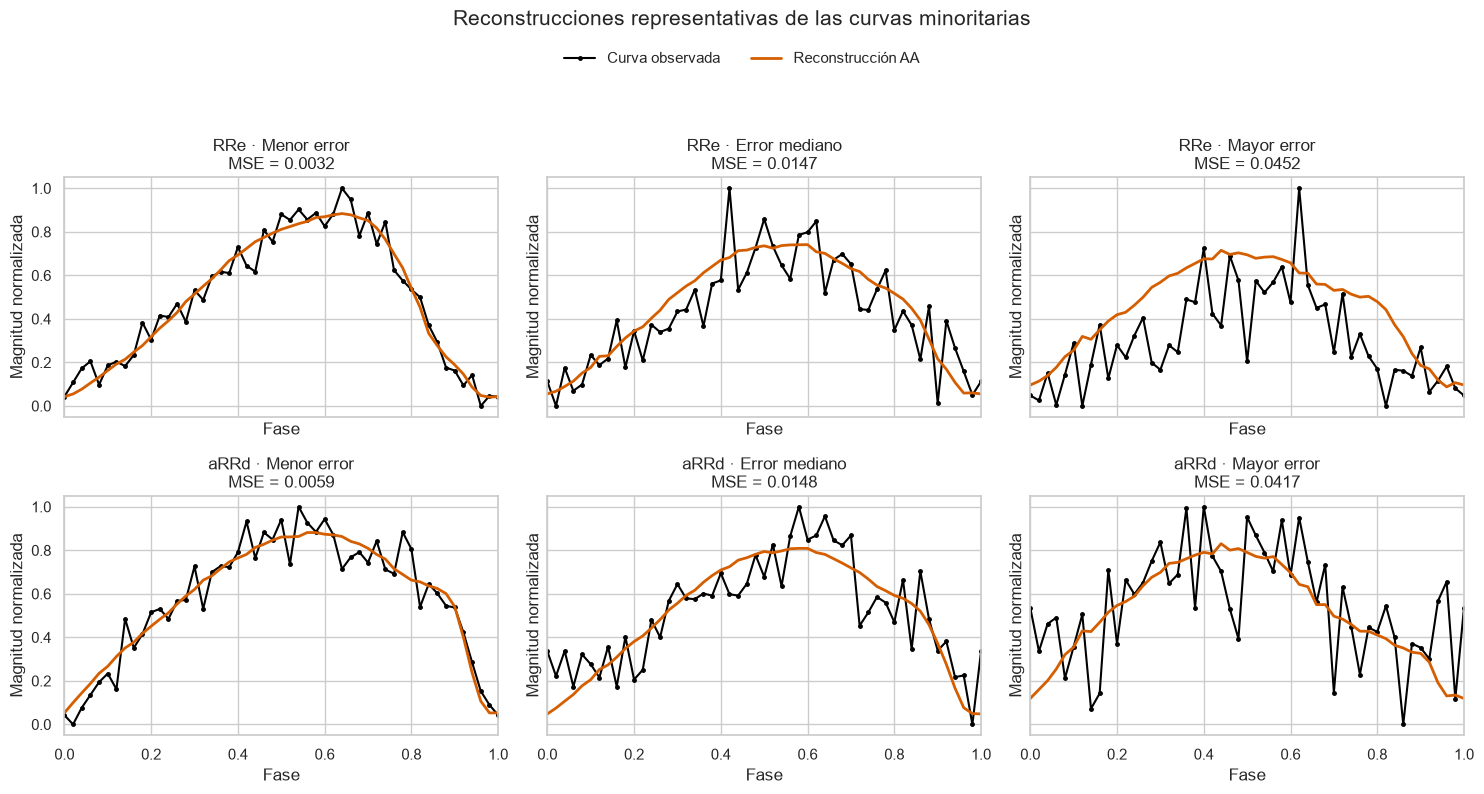

In [15]:
# ---------------------------------------------------------
# Seleccionar reconstrucciones representativas
# ---------------------------------------------------------

seleccion_reconstrucciones = []


for subtipo in ["RRe", "aRRd"]:

    indices_subtipo = np.flatnonzero(
        metadata_minoritarias[
            "subtipo_rrlyrae"
        ].to_numpy() == subtipo
    )

    errores_subtipo = (
        mse_minoritarias[
            indices_subtipo
        ]
    )

    indice_mejor = indices_subtipo[
        np.argmin(errores_subtipo)
    ]

    indice_peor = indices_subtipo[
        np.argmax(errores_subtipo)
    ]

    mediana_error = np.median(
        errores_subtipo
    )

    indice_mediano = indices_subtipo[
        np.argmin(
            np.abs(
                errores_subtipo
                - mediana_error
            )
        )
    ]

    seleccion_reconstrucciones.extend(
        [
            {
                "subtipo": subtipo,
                "caso": "Menor error",
                "indice": indice_mejor,
            },
            {
                "subtipo": subtipo,
                "caso": "Error mediano",
                "indice": indice_mediano,
            },
            {
                "subtipo": subtipo,
                "caso": "Mayor error",
                "indice": indice_peor,
            },
        ]
    )


# ---------------------------------------------------------
# Graficar curvas observadas y reconstruidas
# ---------------------------------------------------------

fase = np.linspace(
    0,
    1,
    X_minoritarias_aa.shape[1],
    endpoint=False,
)

fase_cerrada = np.append(
    fase,
    1.0,
)


fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(15, 8),
    sharex=True,
    sharey=True,
)


for ax, seleccion in zip(
    axes.flat,
    seleccion_reconstrucciones,
):

    indice = seleccion["indice"]

    curva_observada = np.append(
        X_minoritarias_aa[indice],
        X_minoritarias_aa[indice, 0],
    )

    curva_reconstruida = np.append(
        X_reconstruida_minoritarias[
            indice
        ],
        X_reconstruida_minoritarias[
            indice,
            0,
        ],
    )

    ax.plot(
        fase_cerrada,
        curva_observada,
        color="black",
        linewidth=1.5,
        marker="o",
        markersize=2.5,
        label="Curva observada",
    )

    ax.plot(
        fase_cerrada,
        curva_reconstruida,
        color="#D55E00",
        linewidth=2.0,
        label="Reconstrucción AA",
    )

    ax.set_title(
        f"{seleccion['subtipo']} · "
        f"{seleccion['caso']}\n"
        f"MSE = "
        f"{mse_minoritarias[indice]:.4f}"
    )

    ax.set_xlabel("Fase")
    ax.set_ylabel(
        "Magnitud normalizada"
    )

    ax.set_xlim(0, 1)

    # Convención astronómica:
    # menor magnitud representa mayor brillo
    ax.invert_yaxis()


handles, labels = (
    axes[0, 0]
    .get_legend_handles_labels()
)

fig.suptitle(
    "Reconstrucciones representativas "
    "de las curvas minoritarias",
    fontsize=15,
    y=0.99,
)

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.955),
    ncol=2,
    frameon=False,
)

fig.tight_layout(
    rect=[0, 0, 1, 0.90]
)

fig.savefig(
    RUTA_FIGURAS_MINORITARIAS
    / "reconstrucciones_representativas.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

C:\Users\adanm\AppData\Local\Temp\ipykernel_2856\493813846.py:97: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(
C:\Users\adanm\AppData\Local\Temp\ipykernel_2856\493813846.py:97: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(
C:\Users\adanm\AppData\Local\Temp\ipykernel_2856\493813846.py:97: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(
C:\Users\adanm\AppData\Local\Temp\ipykernel_2856\493813846.py:97: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xtick

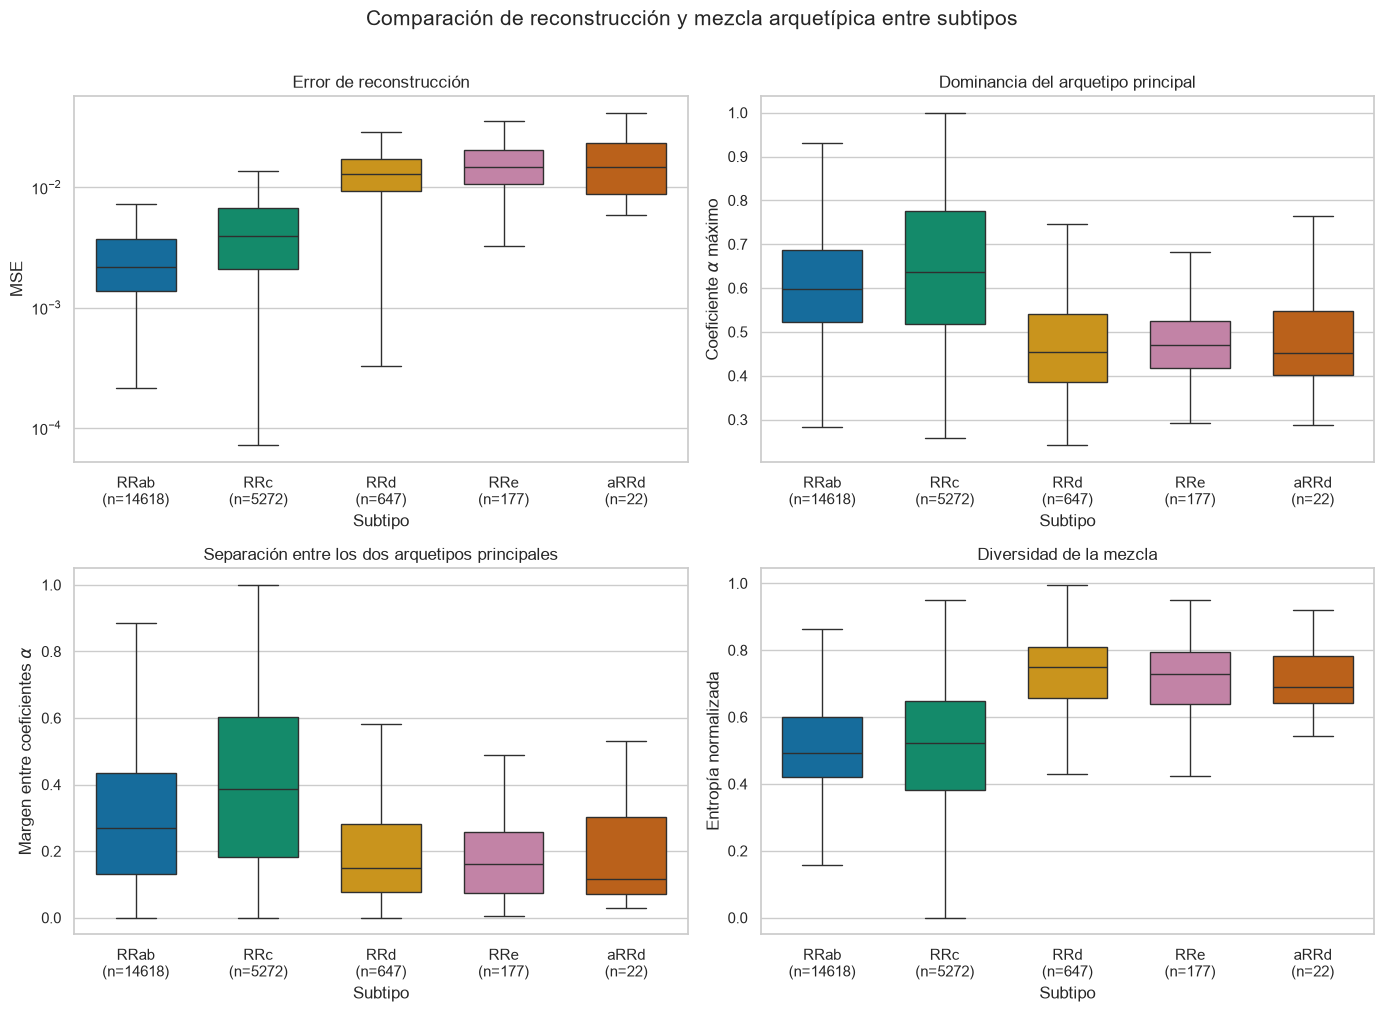

In [16]:
# ---------------------------------------------------------
# Comparación de indicadores entre subtipos
# ---------------------------------------------------------

paleta_subtipos = {
    "RRab": "#0072B2",
    "RRc": "#009E73",
    "RRd": "#E69F00",
    "RRe": "#CC79A7",
    "aRRd": "#D55E00",
}


metricas_grafico = [
    {
        "columna": "mse_reconstruccion",
        "titulo": "Error de reconstrucción",
        "etiqueta_y": "MSE",
        "escala_log": True,
    },
    {
        "columna": "alpha_maximo",
        "titulo": (
            "Dominancia del arquetipo principal"
        ),
        "etiqueta_y": (
            r"Coeficiente $\alpha$ máximo"
        ),
        "escala_log": False,
    },
    {
        "columna": "margen",
        "titulo": (
            "Separación entre los dos "
            "arquetipos principales"
        ),
        "etiqueta_y": (
            r"Margen entre coeficientes $\alpha$"
        ),
        "escala_log": False,
    },
    {
        "columna": "entropia",
        "titulo": "Diversidad de la mezcla",
        "etiqueta_y": "Entropía normalizada",
        "escala_log": False,
    },
]


fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(14, 10),
)


for ax, configuracion in zip(
    axes.flat,
    metricas_grafico,
):

    sns.boxplot(
        data=df_comparacion_subtipos,
        x="subtipo_rrlyrae",
        y=configuracion["columna"],
        order=orden_subtipos,
        hue="subtipo_rrlyrae",
        hue_order=orden_subtipos,
        palette=paleta_subtipos,
        dodge=False,
        showfliers=False,
        width=0.65,
        legend=False,
        ax=ax,
    )

    ax.set_title(
        configuracion["titulo"]
    )

    ax.set_xlabel("Subtipo")
    ax.set_ylabel(
        configuracion["etiqueta_y"]
    )

    if configuracion["escala_log"]:
        ax.set_yscale("log")

    tamanos = (
        df_comparacion_subtipos[
            "subtipo_rrlyrae"
        ]
        .value_counts()
    )

    ax.set_xticklabels(
        [
            f"{subtipo}\n"
            f"(n={tamanos[subtipo]})"
            for subtipo in orden_subtipos
        ]
    )


fig.suptitle(
    "Comparación de reconstrucción y mezcla "
    "arquetípica entre subtipos",
    fontsize=15,
    y=1.01,
)

fig.tight_layout()


fig.savefig(
    RUTA_FIGURAS_MINORITARIAS
    / "comparacion_indicadores_subtipos.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [19]:
# ---------------------------------------------------------
# Recuperar la configuración seleccionada de DBSCAN
# ---------------------------------------------------------

RUTA_CONFIGURACION_CLUSTERING = (
    RUTA_PROYECTO
    / "resultados"
    / "clustering_coeficientes_alpha"
    / "configuracion_clustering.json"
)


with open(
    RUTA_CONFIGURACION_CLUSTERING,
    "r",
    encoding="utf-8",
) as archivo:
    configuracion_clustering = json.load(
        archivo
    )


eps_dbscan = configuracion_clustering[
    "dbscan"
]["eps"]

min_samples_dbscan = (
    configuracion_clustering[
        "dbscan"
    ]["min_samples"]
)


print(
    f"eps: {eps_dbscan:.6f}"
)

print(
    f"min_samples: {min_samples_dbscan}"
)


# ---------------------------------------------------------
# Ajustar DBSCAN únicamente sobre el test principal
# ---------------------------------------------------------

modelo_dbscan_principal = DBSCAN(
    eps=eps_dbscan,
    min_samples=min_samples_dbscan,
)

grupos_dbscan_principal = (
    modelo_dbscan_principal
    .fit_predict(
        alphas_test_principal
    )
)


indices_nucleo = (
    modelo_dbscan_principal
    .core_sample_indices_
)

alphas_nucleo = (
    alphas_test_principal[
        indices_nucleo
    ]
)

grupos_nucleo = (
    grupos_dbscan_principal[
        indices_nucleo
    ]
)


# ---------------------------------------------------------
# Asignación externa de las curvas minoritarias
# ---------------------------------------------------------

vecinos_nucleo = NearestNeighbors(
    n_neighbors=1,
)

vecinos_nucleo.fit(
    alphas_nucleo
)

(
    distancias_nucleo,
    indices_vecinos,
) = vecinos_nucleo.kneighbors(
    alphas_minoritarias
)

distancias_nucleo = (
    distancias_nucleo[:, 0]
)

indices_vecinos = (
    indices_vecinos[:, 0]
)

grupos_vecinos = (
    grupos_nucleo[
        indices_vecinos
    ]
)


grupos_dbscan_minoritarias = np.where(
    distancias_nucleo <= eps_dbscan,
    grupos_vecinos,
    -1,
)


def nombrar_grupo_dbscan(grupo):

    if grupo == -1:
        return "Ruido"

    return f"Grupo {grupo + 1}"


df_resultados_minoritarias[
    "grupo_dbscan"
] = [
    nombrar_grupo_dbscan(grupo)
    for grupo
    in grupos_dbscan_minoritarias
]

df_resultados_minoritarias[
    "distancia_nucleo_dbscan"
] = distancias_nucleo


# ---------------------------------------------------------
# Composición de los grupos principales
# ---------------------------------------------------------

df_dbscan_principal = pd.DataFrame(
    {
        "subtipo_rrlyrae": (
            metadata_test_principal[
                "subtipo_rrlyrae"
            ].to_numpy()
        ),
        "grupo_dbscan": [
            nombrar_grupo_dbscan(grupo)
            for grupo
            in grupos_dbscan_principal
        ],
    }
)


tabla_composicion_principal = (
    pd.crosstab(
        df_dbscan_principal[
            "grupo_dbscan"
        ],
        df_dbscan_principal[
            "subtipo_rrlyrae"
        ],
        normalize="index",
    )
    * 100
)


# ---------------------------------------------------------
# Distribución de RRe y aRRd
# ---------------------------------------------------------

tabla_minoritarias_conteo = pd.crosstab(
    df_resultados_minoritarias[
        "subtipo_rrlyrae"
    ],
    df_resultados_minoritarias[
        "grupo_dbscan"
    ],
)


tabla_minoritarias_porcentaje = (
    pd.crosstab(
        df_resultados_minoritarias[
            "subtipo_rrlyrae"
        ],
        df_resultados_minoritarias[
            "grupo_dbscan"
        ],
        normalize="index",
    )
    * 100
)


print(
    "Composición de los grupos del "
    "test principal:"
)

display(
    tabla_composicion_principal.round(2)
)

print(
    "\nNúmero de curvas minoritarias:"
)

display(
    tabla_minoritarias_conteo
)

print(
    "\nPorcentaje dentro de cada "
    "subtipo minoritario:"
)

display(
    tabla_minoritarias_porcentaje.round(2)
)

eps: 0.068738
min_samples: 50
Composición de los grupos del test principal:


subtipo_rrlyrae,RRab,RRc,RRd
grupo_dbscan,,,
Grupo 1,99.79,0.06,0.15
Grupo 2,6.50,91.28,2.22
Grupo 3,100.00,0.00,0.00
Ruido,42.83,42.83,14.33



Número de curvas minoritarias:


grupo_dbscan,Grupo 1,Grupo 2,Ruido
subtipo_rrlyrae,,,
RRe,2,21,154
aRRd,0,0,22



Porcentaje dentro de cada subtipo minoritario:


grupo_dbscan,Grupo 1,Grupo 2,Ruido
subtipo_rrlyrae,,,
RRe,1.13,11.86,87.01
aRRd,0.00,0.00,100.00


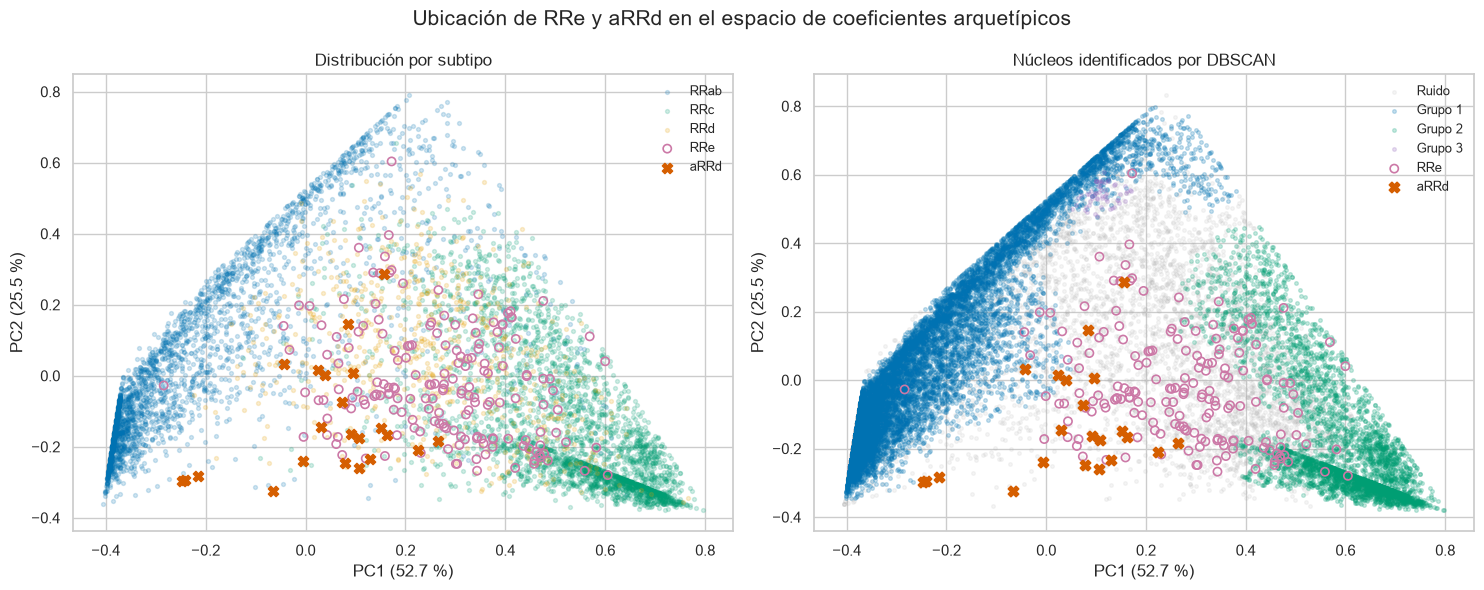

In [21]:
# ---------------------------------------------------------
# Proyección visual del espacio alfa
# ---------------------------------------------------------

pca_alphas = PCA(
    n_components=2
)

coordenadas_principal = (
    pca_alphas.fit_transform(
        alphas_test_principal
    )
)

coordenadas_minoritarias = (
    pca_alphas.transform(
        alphas_minoritarias
    )
)


varianza_pca = (
    pca_alphas
    .explained_variance_ratio_
    * 100
)


# ---------------------------------------------------------
# Selección reproducible para el primer panel
# ---------------------------------------------------------

generador = np.random.default_rng(
    42
)

indices_grafico = []


for subtipo in ["RRab", "RRc", "RRd"]:

    indices_subtipo = np.flatnonzero(
        metadata_test_principal[
            "subtipo_rrlyrae"
        ].to_numpy() == subtipo
    )

    n_seleccion = min(
        3000,
        len(indices_subtipo),
    )

    indices_grafico.extend(
        generador.choice(
            indices_subtipo,
            size=n_seleccion,
            replace=False,
        )
    )


indices_grafico = np.asarray(
    indices_grafico
)


# ---------------------------------------------------------
# Crear figura
# ---------------------------------------------------------

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(15, 6),
)


# Panel 1: subtipos catalogados
for subtipo in ["RRab", "RRc", "RRd"]:

    mascara = (
        metadata_test_principal[
            "subtipo_rrlyrae"
        ]
        .to_numpy()[
            indices_grafico
        ]
        == subtipo
    )

    indices = indices_grafico[
        mascara
    ]

    axes[0].scatter(
        coordenadas_principal[
            indices,
            0,
        ],
        coordenadas_principal[
            indices,
            1,
        ],
        s=8,
        alpha=0.18,
        color=paleta_subtipos[
            subtipo
        ],
        label=subtipo,
    )


axes[0].scatter(
    coordenadas_minoritarias[
        metadata_minoritarias[
            "subtipo_rrlyrae"
        ].to_numpy() == "RRe",
        0,
    ],
    coordenadas_minoritarias[
        metadata_minoritarias[
            "subtipo_rrlyrae"
        ].to_numpy() == "RRe",
        1,
    ],
    s=35,
    facecolors="none",
    edgecolors=paleta_subtipos["RRe"],
    linewidths=1.2,
    label="RRe",
)

axes[0].scatter(
    coordenadas_minoritarias[
        metadata_minoritarias[
            "subtipo_rrlyrae"
        ].to_numpy() == "aRRd",
        0,
    ],
    coordenadas_minoritarias[
        metadata_minoritarias[
            "subtipo_rrlyrae"
        ].to_numpy() == "aRRd",
        1,
    ],
    s=55,
    marker="X",
    color=paleta_subtipos["aRRd"],
    label="aRRd",
)

axes[0].set_title(
    "Distribución por subtipo"
)


# Panel 2: estructura de DBSCAN
colores_dbscan = {
    -1: "#B0B0B0",
    0: "#0072B2",
    1: "#009E73",
    2: "#9467BD",
}


for grupo in sorted(
    np.unique(
        grupos_dbscan_principal
    )
):

    mascara = (
        grupos_dbscan_principal
        == grupo
    )

    etiqueta = (
        "Ruido"
        if grupo == -1
        else f"Grupo {grupo + 1}"
    )

    axes[1].scatter(
        coordenadas_principal[
            mascara,
            0,
        ],
        coordenadas_principal[
            mascara,
            1,
        ],
        s=7,
        alpha=(
            0.12
            if grupo == -1
            else 0.22
        ),
        color=colores_dbscan[
            grupo
        ],
        label=etiqueta,
    )


for subtipo, marcador in [
    ("RRe", "o"),
    ("aRRd", "X"),
]:

    mascara = (
        metadata_minoritarias[
            "subtipo_rrlyrae"
        ].to_numpy()
        == subtipo
    )

    axes[1].scatter(
        coordenadas_minoritarias[
            mascara,
            0,
        ],
        coordenadas_minoritarias[
            mascara,
            1,
        ],
        s=(
            35
            if subtipo == "RRe"
            else 55
        ),
        marker=marcador,
        facecolors=(
            "none"
            if subtipo == "RRe"
            else paleta_subtipos[subtipo]
        ),
        edgecolors=paleta_subtipos[
            subtipo
        ],
        linewidths=1.2,
        label=subtipo,
    )


axes[1].set_title(
    "Núcleos identificados por DBSCAN"
)


for ax in axes:

    ax.set_xlabel(
        f"PC1 ({varianza_pca[0]:.1f} %)"
    )

    ax.set_ylabel(
        f"PC2 ({varianza_pca[1]:.1f} %)"
    )

    ax.legend(
        frameon=False,
        fontsize=9,
    )


fig.suptitle(
    "Ubicación de RRe y aRRd en el "
    "espacio de coeficientes arquetípicos",
    fontsize=15,
)

fig.tight_layout()


fig.savefig(
    RUTA_FIGURAS_MINORITARIAS
    / "mapa_pca_espacio_alpha_minoritarias.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [23]:



# ---------------------------------------------------------
# Agregar indicadores por estrella física
# ---------------------------------------------------------

metricas_efecto = [
    "mse_reconstruccion",
    "alpha_maximo",
    "margen",
    "entropia",
]


df_comparacion_estrellas = (
    df_comparacion_subtipos
    .groupby(
        [
            "star_id_base",
            "subtipo_rrlyrae",
        ],
        as_index=False,
    )
    .agg(
        n_curvas=(
            "observacion_id",
            "size",
        ),
        **{
            metrica: (
                metrica,
                "mean",
            )
            for metrica
            in metricas_efecto
        },
    )
)


resumen_estrellas = (
    df_comparacion_estrellas
    .groupby("subtipo_rrlyrae")
    .agg(
        n_estrellas=(
            "star_id_base",
            "nunique",
        ),
        n_curvas=(
            "n_curvas",
            "sum",
        ),
    )
    .reindex(orden_subtipos)
    .reset_index()
)


display(resumen_estrellas)


# ---------------------------------------------------------
# Calcular delta de Cliff
# ---------------------------------------------------------

resultados_delta = []


for metrica in metricas_efecto:

    for subtipo_1, subtipo_2 in combinations(
        orden_subtipos,
        2,
    ):

        valores_1 = (
            df_comparacion_estrellas.loc[
                df_comparacion_estrellas[
                    "subtipo_rrlyrae"
                ]
                == subtipo_1,
                metrica,
            ]
            .dropna()
            .to_numpy()
        )

        valores_2 = (
            df_comparacion_estrellas.loc[
                df_comparacion_estrellas[
                    "subtipo_rrlyrae"
                ]
                == subtipo_2,
                metrica,
            ]
            .dropna()
            .to_numpy()
        )

        estadistico_u = mannwhitneyu(
            valores_1,
            valores_2,
            alternative="two-sided",
            method="asymptotic",
        ).statistic

        delta_cliff = (
            2
            * estadistico_u
            / (
                len(valores_1)
                * len(valores_2)
            )
            - 1
        )

        resultados_delta.append(
            {
                "metrica": metrica,
                "subtipo_1": subtipo_1,
                "subtipo_2": subtipo_2,
                "n_1": len(valores_1),
                "n_2": len(valores_2),
                "mediana_1": np.median(
                    valores_1
                ),
                "mediana_2": np.median(
                    valores_2
                ),
                "delta_cliff": (
                    delta_cliff
                ),
            }
        )


df_delta_cliff = pd.DataFrame(
    resultados_delta
)


# Comparaciones centrales para este análisis
pares_interes = {
    ("RRc", "RRe"),
    ("RRc", "aRRd"),
    ("RRd", "RRe"),
    ("RRd", "aRRd"),
    ("RRe", "aRRd"),
}


df_delta_interes = (
    df_delta_cliff.loc[
        df_delta_cliff.apply(
            lambda fila: (
                fila["subtipo_1"],
                fila["subtipo_2"],
            )
            in pares_interes,
            axis=1,
        )
    ]
    .reset_index(drop=True)
)


display(
    df_delta_interes.round(4)
)

,subtipo_rrlyrae,n_estrellas,n_curvas
0,RRab,9875,14618
1,RRc,3696,5272
2,RRd,443,647
3,RRe,177,177
4,aRRd,22,22


,metrica,subtipo_1,subtipo_2,n_1,n_2,mediana_1,mediana_2,delta_cliff
0,mse_reconstruccion,RRc,RRe,3696,177,0.0040,0.0147,-0.8306
1,mse_reconstruccion,RRc,aRRd,3696,22,0.0040,0.0147,-0.8322
2,mse_reconstruccion,RRd,RRe,443,177,0.0127,0.0147,-0.1702
3,mse_reconstruccion,RRd,aRRd,443,22,0.0127,0.0147,-0.1666
4,mse_reconstruccion,RRe,aRRd,177,22,0.0147,0.0147,-0.0247
5,alpha_maximo,RRc,RRe,3696,177,0.6369,0.4704,0.6330
6,alpha_maximo,RRc,aRRd,3696,22,0.6369,0.4509,0.5898
7,alpha_maximo,RRd,RRe,443,177,0.4586,0.4704,-0.0201
8,alpha_maximo,RRd,aRRd,443,22,0.4586,0.4509,0.0322
9,alpha_maximo,RRe,aRRd,177,22,0.4704,0.4509,0.0683


In [24]:
# ---------------------------------------------------------
# Directorios de salida
# ---------------------------------------------------------

RUTA_TABLAS_MINORITARIAS = (
    RUTA_SALIDA_MINORITARIAS
    / "tablas"
)

RUTA_ARTEFACTOS_MINORITARIAS = (
    RUTA_SALIDA_MINORITARIAS
    / "artefactos"
)

RUTA_TABLAS_MINORITARIAS.mkdir(
    parents=True,
    exist_ok=True,
)

RUTA_ARTEFACTOS_MINORITARIAS.mkdir(
    parents=True,
    exist_ok=True,
)


# ---------------------------------------------------------
# Guardar tablas
# ---------------------------------------------------------

tablas_sin_indice = {
    "resultados_minoritarias.csv": (
        df_resultados_minoritarias
    ),
    "resumen_mezcla_minoritarias.csv": (
        resumen_mezcla_minoritarias
    ),
    "resumen_comparacion_subtipos.csv": (
        resumen_comparacion_subtipos
    ),
    "comparacion_indicadores_curvas.csv": (
        df_comparacion_subtipos
    ),
    "comparacion_indicadores_estrellas.csv": (
        df_comparacion_estrellas
    ),
    "resumen_estrellas.csv": (
        resumen_estrellas
    ),
    "delta_cliff_completo.csv": (
        df_delta_cliff
    ),
    "delta_cliff_interes.csv": (
        df_delta_interes
    ),
}


for nombre_archivo, tabla in (
    tablas_sin_indice.items()
):
    tabla.to_csv(
        RUTA_TABLAS_MINORITARIAS
        / nombre_archivo,
        index=False,
    )


tablas_con_indice = {
    "arquetipo_dominante_conteo.csv": (
        tabla_arquetipo_conteo
    ),
    "arquetipo_dominante_porcentaje.csv": (
        tabla_arquetipo_porcentaje
    ),
    "alphas_promedio_subtipo.csv": (
        tabla_alphas_promedio
    ),
    "composicion_dbscan_principal.csv": (
        tabla_composicion_principal
    ),
    "asignacion_dbscan_minoritarias_conteo.csv": (
        tabla_minoritarias_conteo
    ),
    "asignacion_dbscan_minoritarias_porcentaje.csv": (
        tabla_minoritarias_porcentaje
    ),
}


for nombre_archivo, tabla in (
    tablas_con_indice.items()
):
    tabla.to_csv(
        RUTA_TABLAS_MINORITARIAS
        / nombre_archivo,
        index=True,
    )


# ---------------------------------------------------------
# Guardar matrices y vectores
# ---------------------------------------------------------

artefactos_numpy = {
    "ids_minoritarias.npy": (
        metadata_minoritarias[
            "observacion_id"
        ].to_numpy()
    ),
    "subtipos_minoritarias.npy": (
        metadata_minoritarias[
            "subtipo_rrlyrae"
        ].to_numpy()
    ),
    "alphas_minoritarias.npy": (
        alphas_minoritarias
    ),
    "reconstrucciones_minoritarias.npy": (
        X_reconstruida_minoritarias
    ),
    "mse_minoritarias.npy": (
        mse_minoritarias
    ),
    "grupos_dbscan_minoritarias.npy": (
        grupos_dbscan_minoritarias
    ),
    "distancias_nucleo_dbscan.npy": (
        distancias_nucleo
    ),
    "coordenadas_pca_minoritarias.npy": (
        coordenadas_minoritarias
    ),
    "pca_componentes.npy": (
        pca_alphas.components_
    ),
    "pca_media.npy": (
        pca_alphas.mean_
    ),
    "pca_varianza_explicada.npy": (
        pca_alphas
        .explained_variance_ratio_
    ),
}


for nombre_archivo, arreglo in (
    artefactos_numpy.items()
):
    np.save(
        RUTA_ARTEFACTOS_MINORITARIAS
        / nombre_archivo,
        arreglo,
    )


# ---------------------------------------------------------
# Guardar configuración
# ---------------------------------------------------------

configuracion_minoritarias = {
    "unidad_analisis": "curva_de_luz",
    "numero_curvas": int(
        len(metadata_minoritarias)
    ),
    "numero_rre": int(
        (
            metadata_minoritarias[
                "subtipo_rrlyrae"
            ]
            == "RRe"
        ).sum()
    ),
    "numero_arrd": int(
        (
            metadata_minoritarias[
                "subtipo_rrlyrae"
            ]
            == "aRRd"
        ).sum()
    ),
    "representacion": "medianas_fase_50",
    "normalizacion": "minmax_por_curva",
    "aa_experimento": ID_AA_REFERENCIA,
    "numero_arquetipos": 5,
    "proyeccion": "NNLS_con_restriccion_aproximada_de_suma",
    "dbscan": {
        "eps": float(
            eps_dbscan
        ),
        "min_samples": int(
            min_samples_dbscan
        ),
        "regla_externa": (
            "Asignación al grupo de la observación "
            "núcleo más cercana cuando la distancia "
            "es menor o igual que eps; en caso "
            "contrario se asigna ruido."
        ),
    },
    "advertencias": [
        (
            "Ruido significa fuera de los núcleos "
            "densos y no implica datos defectuosos."
        ),
        (
            "Los resultados de aRRd son "
            "exploratorios debido a n=22."
        ),
    ],
}


with open(
    RUTA_SALIDA_MINORITARIAS
    / "configuracion_analisis.json",
    "w",
    encoding="utf-8",
) as archivo:
    json.dump(
        configuracion_minoritarias,
        archivo,
        ensure_ascii=False,
        indent=4,
    )


# ---------------------------------------------------------
# Crear manifiesto final
# ---------------------------------------------------------

archivos_finales = []


for ruta in sorted(
    RUTA_SALIDA_MINORITARIAS.rglob("*")
):
    if not ruta.is_file():
        continue

    archivos_finales.append(
        {
            "archivo": str(
                ruta.relative_to(
                    RUTA_SALIDA_MINORITARIAS
                )
            ),
            "extension": ruta.suffix.lower(),
            "tamano_kb": (
                ruta.stat().st_size
                / 1024
            ),
        }
    )


df_manifiesto_minoritarias = (
    pd.DataFrame(archivos_finales)
)


df_manifiesto_minoritarias.to_csv(
    RUTA_SALIDA_MINORITARIAS
    / "manifiesto_archivos.csv",
    index=False,
)


print(
    "Resultados guardados en:"
)

print(
    RUTA_SALIDA_MINORITARIAS
)

print(
    f"\nArchivos guardados: "
    f"{len(df_manifiesto_minoritarias)}"
)

display(
    df_manifiesto_minoritarias.round(
        {"tamano_kb": 2}
    )
)

Resultados guardados en:
C:\Users\adanm\Code\tesis\resultados\analisis_minoritarias

Archivos guardados: 29


,archivo,extension,tamano_kb
0,artefactos\alphas_minoritarias.npy,.npy,7.90
1,artefactos\coordenadas_pca_minoritarias.npy,.npy,3.23
2,artefactos\distancias_nucleo_dbscan.npy,.npy,1.68
3,artefactos\grupos_dbscan_minoritarias.npy,.npy,1.68
4,artefactos\ids_minoritarias.npy,.npy,6.25
5,artefactos\mse_minoritarias.npy,.npy,1.68
6,artefactos\pca_componentes.npy,.npy,0.20
7,artefactos\pca_media.npy,.npy,0.16
8,artefactos\pca_varianza_explicada.npy,.npy,0.14
9,artefactos\reconstrucciones_minoritarias.npy,.npy,77.86


## Conclusiones

Proyectamos 199 curvas minoritarias —177 RRe y 22 aRRd— sobre los cinco arquetipos aprendidos exclusivamente con RRab, RRc y RRd. Cada curva corresponde a una estrella física diferente, por lo que este análisis no contiene observaciones repetidas de una misma estrella. La proyección se realizó sin reentrenar AA ni modificar los parámetros seleccionados.

Las RRe presentaron un coeficiente máximo medio de 0,4800, un margen medio de 0,1842 y una entropía media de 0,7031. Las aRRd alcanzaron valores respectivos de 0,4829, 0,1872 y 0,6812. Estos resultados muestran una menor dominancia de un arquetipo individual y mezclas más distribuidas que las observadas en RRab y RRc. Ambas clases minoritarias presentaron valores cercanos a RRd, cuya entropía media fue de 0,7266.

La composición media de los coeficientes mostró diferencias entre las clases minoritarias. Las RRe presentaron sus mayores aportes en los arquetipos 2 y 5, asociados principalmente con RRc. Sin embargo, sus coeficientes fueron más distribuidos que los de las RRc. Las aRRd combinaron principalmente el arquetipo 3, asociado con RRab, y el arquetipo 2, asociado con RRc, lo que refleja una representación morfológica mixta.

Los arquetipos reprodujeron adecuadamente la forma global de las curvas minoritarias, aunque sus errores fueron superiores a los de RRab y RRc. El MSE medio fue de 0,0162 para RRe y de 0,0170 para aRRd, frente a 0,0031 para RRab, 0,0052 para RRc y 0,0139 para RRd. Las reconstrucciones conservaron la tendencia principal de las curvas, pero suavizaron oscilaciones locales y puntos extremos.

La asignación externa mediante DBSCAN mostró que el 87,01 % de las RRe y el 100 % de las aRRd quedaron fuera de los núcleos densos identificados en el conjunto principal. Solo el 11,86 % de las RRe se incorporó al grupo asociado principalmente con RRc. En este contexto, la clasificación como ruido indica que una observación se encuentra fuera de las regiones densas y no implica que corresponda a un dato defectuoso.

La representación bidimensional mediante PCA conservó el 78,2 % de la variación del espacio de coeficientes. En ella, RRab y RRc ocuparon regiones opuestas, mientras que RRd, RRe y aRRd se distribuyeron principalmente en zonas intermedias o poco densas.

Los tamaños de efecto calculados por estrella física respaldaron esta interpretación. Las diferencias entre RRc y las clases minoritarias fueron amplias, mientras que las diferencias entre RRd y RRe o aRRd fueron pequeñas. RRe y aRRd también presentaron tamaños de efecto cercanos a cero entre sí. Por lo tanto, dentro de la representación y el modelo seleccionados, ambas clases minoritarias mostraron un comportamiento más próximo a las mezclas morfológicas observadas en RRd que a los núcleos compactos de RRc.

Los resultados de aRRd deben considerarse exploratorios debido a que solo se dispone de 22 observaciones. Asimismo, la asignación externa de DBSCAN se realizó mediante la distancia al punto núcleo más cercano, ya que el algoritmo no posee un método de predicción para observaciones nuevas. Las clases minoritarias no participaron en el entrenamiento ni en la selección de parámetros.